# With vs. without satellite levels

Compares two runs of the same seeded Cu K$\alpha$1 RSA simulation:

- **without satellites** &mdash; `config/base/Cu-seed.yaml` (plain 6-level 1s/2p$_{3/2}$ system)
- **with satellites** &mdash; `config/base/Cu-seed-satellite.yaml` (same base system, plus the four
  2s-hole satellite channels `3d+`, `3d-`, `3p+`, `3p-`, see `docs/theory-and-2s-satellite-pathways.md`)

Both runs use the same seed field, grid, and random seed, so any difference in the results is due to
the satellite channels alone.

**Note on "2p+"/"2p-":** in this code's notation $2p^+ = 2p_{3/2}$ (L3, the only 2p level the base
6-level system tracks) and $2p^- = 2p_{1/2}$ (L2). Tracking $2p^-$ requires `use_L2_pathway: True`,
which is not yet compatible with `satellite_channels` (the code raises an error if both are set) &mdash;
so `Cu-seed-satellite.yaml` has `use_L2_pathway: False` and only $2p^+$ is available here. This
notebook therefore plots 1s and $2p^+$ populations for both runs, plus the new satellite-channel
populations (upper "1s+spectator" and lower "$2p^+$+spectator" states) for the with-satellites run.

### Import libraries

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt

from XLO_sim.XLO_sim import XLO_sim
from XLO_sim import tools

notebook_path = os.path.abspath("__file__")
notebook_directory = os.path.dirname(notebook_path)
base_directory = os.path.dirname(notebook_directory)

initializing ocelot...


### Run both configurations

In [2]:
def run_config(config_path, random_seed=42, tpad=1000, ypad=64):
    """Run one seeded 3D simulation and post-process it into transmittance + population arrays."""
    X = XLO_sim(config_path)
    X.random_seed = random_seed
    seed_field = tools.Gaussian_pulse_aniso_seed(X)
    X.configure(seed_field)
    X.run_3D()
    outputs = tools.compute_run_outputs(X, tpad=tpad, ypad=ypad)
    return X, outputs

In [3]:
config_no_satellite = base_directory + '/config/base/Cu-seed.yaml'
config_satellite = base_directory + '/config/base/Cu-seed-satellite.yaml'

X_no_sat, out_no_sat = run_config(config_no_satellite)
X_sat, out_sat = run_config(config_satellite)

print('satellite channels:', out_sat['satellite_channel_names'])

norm =  0.9999508432645734
number of seed photons = 3.1e+10
norm =  0.9999508432645734
number of seed photons = 3.1e+10
satellite channels: ('3d+', '3d-', '3p+', '3p-')


### Transmittance

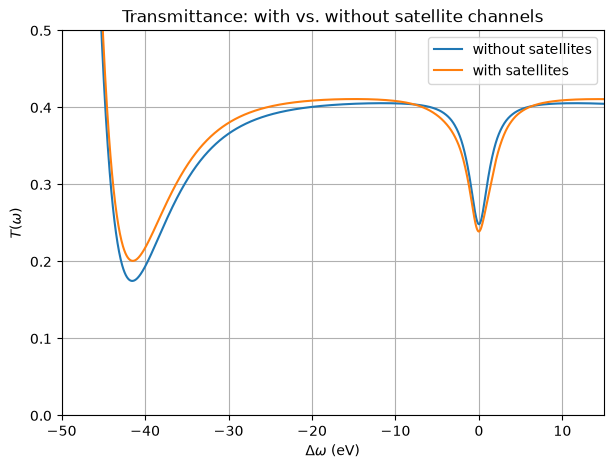

In [4]:
plt.figure(figsize=(7, 5))

for label, out in [('without satellites', out_no_sat), ('with satellites', out_sat)]:
    T_w = np.real(out['I_int_thy_w_last']) / np.real(out['I_int_thy_w_0'])
    plt.plot(out['womega_ar'], T_w, label=label)

plt.xlabel(r'$\Delta\omega$ (eV)')
plt.ylabel(r'$T(\omega)$')
plt.xlim(-50, 15)
plt.ylim(0, 0.5)
plt.grid(True)
plt.legend()
plt.title('Transmittance: with vs. without satellite channels')
plt.show()

### 1s and 2p$^+$ (2p$_{3/2}$) populations

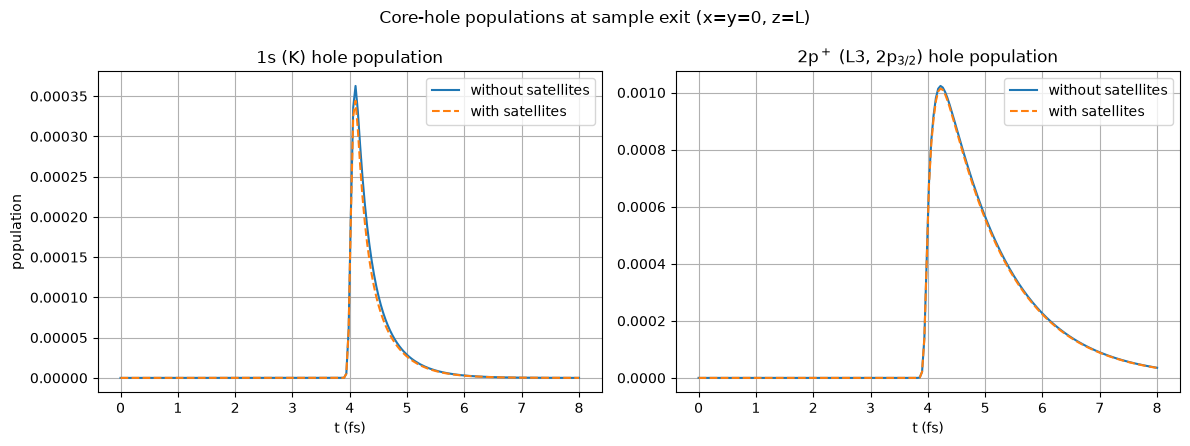

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)

for label, out, style in [('without satellites', out_no_sat, '-'), ('with satellites', out_sat, '--')]:
    t = out['t_axis']
    axes[0].plot(t, np.real(out['rho_ee_t_last']), style, label=label)
    axes[1].plot(t, np.real(out['rho_gg_t_last']), style, label=label)

axes[0].set_title('1s (K) hole population')
axes[1].set_title(r'2p$^+$ (L3, 2p$_{3/2}$) hole population')
for ax in axes:
    ax.set_xlabel('t (fs)')
    ax.grid(True)
    ax.legend()
axes[0].set_ylabel('population')

plt.suptitle('Core-hole populations at sample exit (x=y=0, z=L)')
plt.tight_layout()
plt.show()

### Satellite channel populations (with-satellites run)

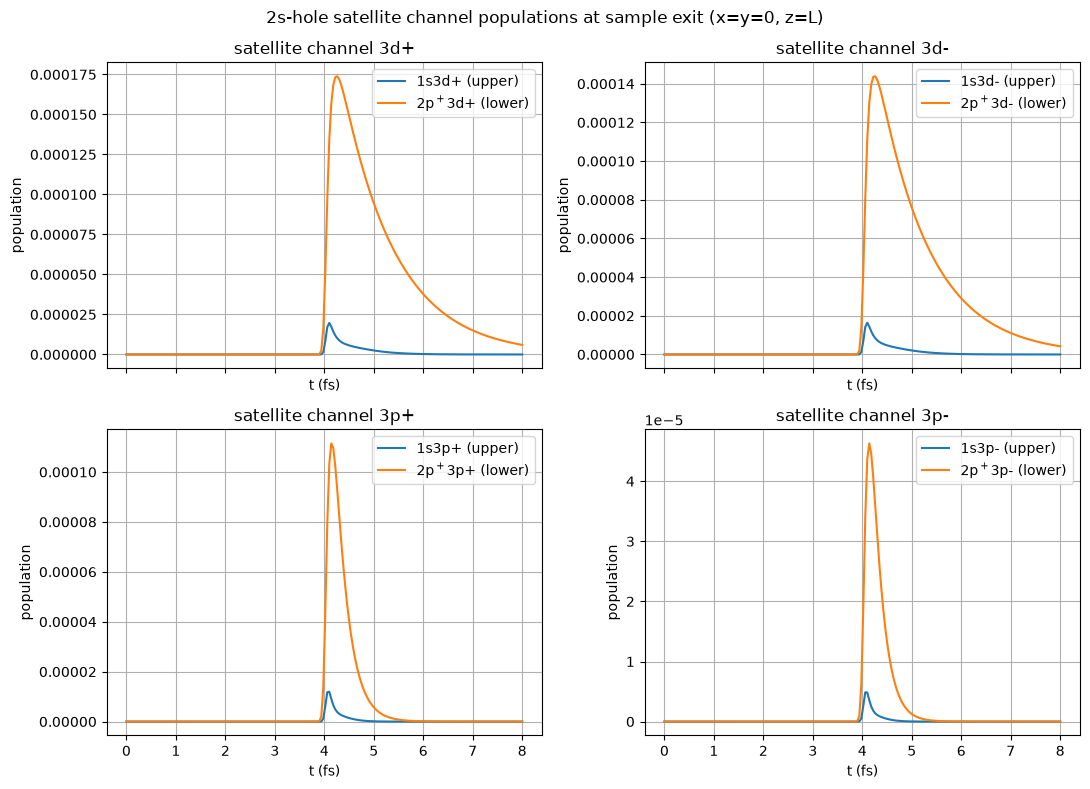

In [6]:
names = out_sat['satellite_channel_names']
t = out_sat['t_axis']

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)

for k, name in enumerate(names):
    ax = axes.flat[k]
    ax.plot(t, np.real(out_sat['rho_ee_t_last_sat'][k]), label=f'1s{name} (upper)')
    ax.plot(t, np.real(out_sat['rho_gg_t_last_sat'][k]), label=f'2p$^+${name} (lower)')
    ax.set_title(f'satellite channel {name}')
    ax.set_xlabel('t (fs)')
    ax.set_ylabel('population')
    ax.grid(True)
    ax.legend()

plt.suptitle('2s-hole satellite channel populations at sample exit (x=y=0, z=L)')
plt.tight_layout()
plt.show()